# Spheroid evaluation

In [1]:
%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings('ignore')

import os
import sys

cwd = os.getcwd()
S2F_ROOT = os.path.normpath(os.path.join(cwd, ".."))
sys.path.insert(0, S2F_ROOT)

import torch
from models.s2f_model import create_s2f_model
from data.cell_dataset import load_folder_data
from utils.metrics import evaluate_metrics_on_dataset, print_metrics_report, plot_predictions

## 1. Config

In [2]:
DATA_FOLDER = os.path.join(S2F_ROOT, 'dataset', 'spheroid', 'test')
CHECKPOINT_PATH = os.path.join(S2F_ROOT, 'ckp', 'spheroid', 'ckp_spheroid_FN.pth')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BATCH_SIZE = 8

## 2. Load model 

In [3]:
generator, _ = create_s2f_model(in_channels=1, model_type='s2f_spheroid')

checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
state_dict = checkpoint.get('generator_state_dict') or checkpoint.get('model_state_dict') or checkpoint
generator.load_state_dict(state_dict, strict=True)

generator.set_output_mode(use_tanh=False)
generator = generator.to(DEVICE)
generator.eval()
print('S2FSpheroidGenerator loaded from', CHECKPOINT_PATH)

Generator set to sigmoid output mode [0, 1] for inference/evaluation
S2FSpheroidGenerator loaded from c:\Users\Kaveh\Documents\Shape2Force\ckp\spheroid\ckp_spheroid_FN.pth


## 3. Load data

In [4]:
val_loader = load_folder_data(
    DATA_FOLDER,
    substrate=None,
    img_size=1024,
    batch_size=BATCH_SIZE,
    return_metadata=False,
)
print(f"Val samples: {len(val_loader.dataset)}")

Val samples: 28


## 4. Plot predictions

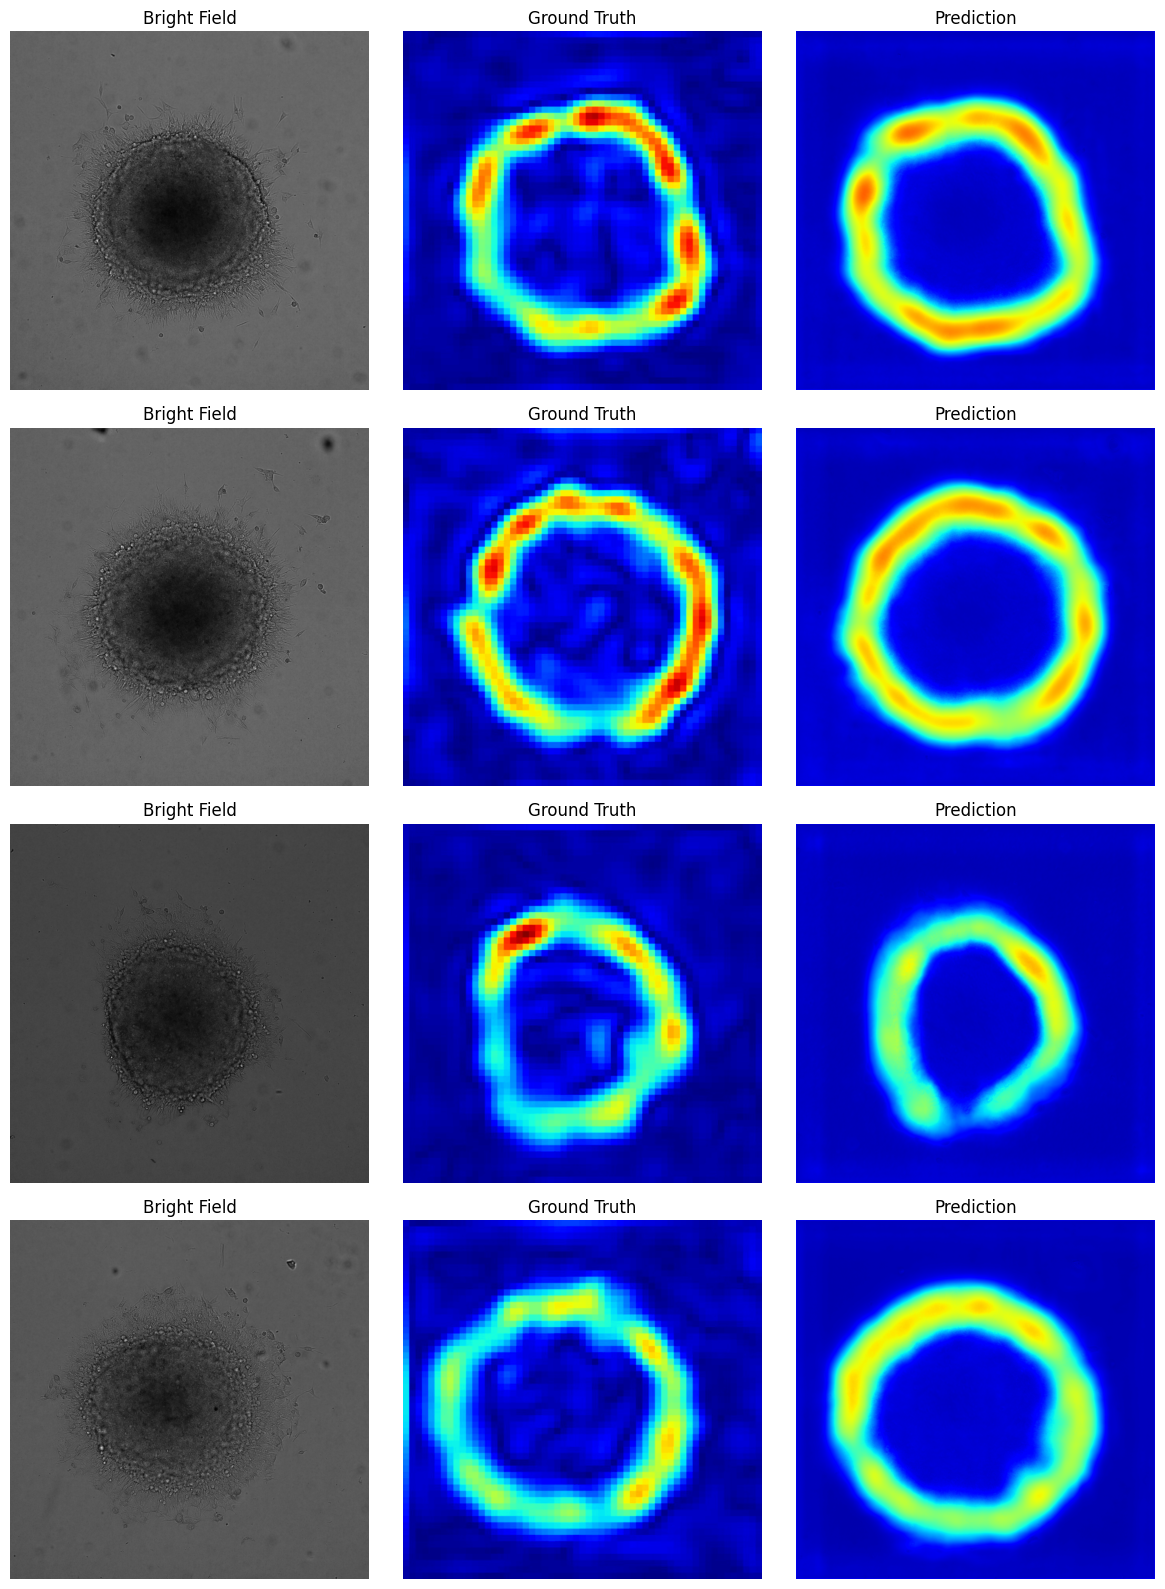

In [5]:
plot_predictions(
    val_loader,
    generator,
    n_samples=4,
    device=DEVICE,
    threshold=0.0,
    use_settings=False,
    normalization_params=None,
    config_path=None
)

## 5. Evaluation

In [6]:
val_results = evaluate_metrics_on_dataset(
    generator,
    val_loader,
    device=DEVICE,
    description='Validation',
    save_predictions=False,
    threshold=0.0,
    use_settings=False,
    normalization_params=None,
    config_path=None
)

report = {'val': val_results}
print_metrics_report(report, uses_tanh=False)

Validation: 100%|██████████| 4/4 [00:03<00:00,  1.05it/s]


🔸 VAL SET METRICS
------------------------------------------------------------
HEATMAP METRICS:
 MSE:             0.013553 ± 0.003707
 MS-SSIM:         0.7865 ± 0.0227
 Pixel Corr:      0.8779 ± 0.0824
 Correlation (Magnitude): 0.8723 ± 0.0234
 Relative Magnitude Error: 0.4133 ± 0.0387
FORCE SUM CORRELATION:
 Correlation: 0.6507
 GT Mean: 178588.76 ± 45433.88
 Pred Mean: 184157.72 ± 28380.52
